# Core \#1 — Per-Instrument Volatility / Turbulence HMM

**Project:** STML Metamodel Feature Engineering
**Author:** Harry Browne
**Model:** Gaussian HMM, M = 3 states, d = 1 observation per day per instrument
**Purpose:** Generate causal, leakage-free volatility-regime features for the 645-day
metamodel window (2020-01-03 → 2022-06-30).

---

This notebook documents the design, fitting, diagnostics, and feature-extraction
pipeline for the **per-instrument volatility HMM** (Core \#1 of the metamodel
feature set).  The structure follows the HMM conventions from
*Programming Session 3* (Rabiner 1989 notation), adapted from discrete to
**Gaussian continuous emissions**.

### Outline

1. [Observation choice — Garman-Klass log vol](#obs)
2. [Pre-sample split and standardisation](#split)
3. [Fit-and-freeze design: why it is leakage-free](#design)
4. [EM fitting with multiple random restarts](#fit)
5. [Learned parameters: transition matrix and state means](#params)
6. [Regime-over-time plot](#regime)
7. [Dwell-time sanity check](#dwell)
8. [Filter-forward into the metamodel window](#filter)
9. [Feature extraction and preview](#features)


In [1]:
import warnings
warnings.filterwarnings("ignore")

import sys, os
sys.path.insert(0, os.path.join(os.path.dirname(os.getcwd()), "..", "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from pathlib import Path
from hmmlearn.hmm import GaussianHMM
from scipy.special import logsumexp

np.random.seed(42)
sns.set_theme(style="whitegrid", palette="muted")

REPO      = Path("../..").resolve()
OHLCV_PATH = REPO / "data" / "ohlcv_data.csv"
PS_PATH    = REPO / "data" / "primary_signals.csv"
OUT_PATH   = REPO / "src" / "stml" / "new_work" / "features_hmm_vol.csv"

INSTRUMENTS = ["es1s","nq1s","fesx1s","cl1s","ho1s","rb1s","ng1s","gc1s","si1s","hg1s","pl1s"]
N_STATES = 3
N_RESTARTS = 20
N_ITER = 300

ohlcv = pd.read_csv(OHLCV_PATH, parse_dates=["date"])
ps    = pd.read_csv(PS_PATH,    parse_dates=["date"])

CUTOFF     = ps["date"].min()   # 2020-01-03
META_DATES = set(ps["date"])
print(f"OHLCV rows: {len(ohlcv):,}  |  Pre-sample cutoff: {CUTOFF.date()}  |  Meta window: {len(ps)} days")


OHLCV rows: 83,547  |  Pre-sample cutoff: 2020-01-03  |  Meta window: 645 days


---
<a id="obs"></a>
## 1  Observation Choice — Garman-Klass Log Volatility

### Why Garman-Klass?

The standard close-to-close return standard deviation uses only one price per bar.
Garman & Klass (1980) show that incorporating the intraday range (H and L) and the
open produces an estimator with roughly **½ the variance** of the close-to-close
estimator at the same sample size:

$$\sigma^2_{\text{GK},t} = 0.5\,\bigl(\ln H_t - \ln L_t\bigr)^2
    - (2\ln 2 - 1)\,\bigl(\ln C_t - \ln O_t\bigr)^2$$

Because the HMM must infer latent regimes from a *single* daily observation, a
lower-noise estimator translates directly into cleaner state separation.

We then take $\log\sigma^2_{\text{GK}}$ to make the observation more Gaussian
(vol-of-vol tends to be log-normal in practice) and to stabilise the variance
across the wide range of turbulence levels.

**Alternative:** a 10–20 day rolling std of log-returns would be smoother but
introduces a backward-looking window that **lags** regime changes by up to 20 days.
GK gives a *daily* signal with no lookback lag beyond the current bar.


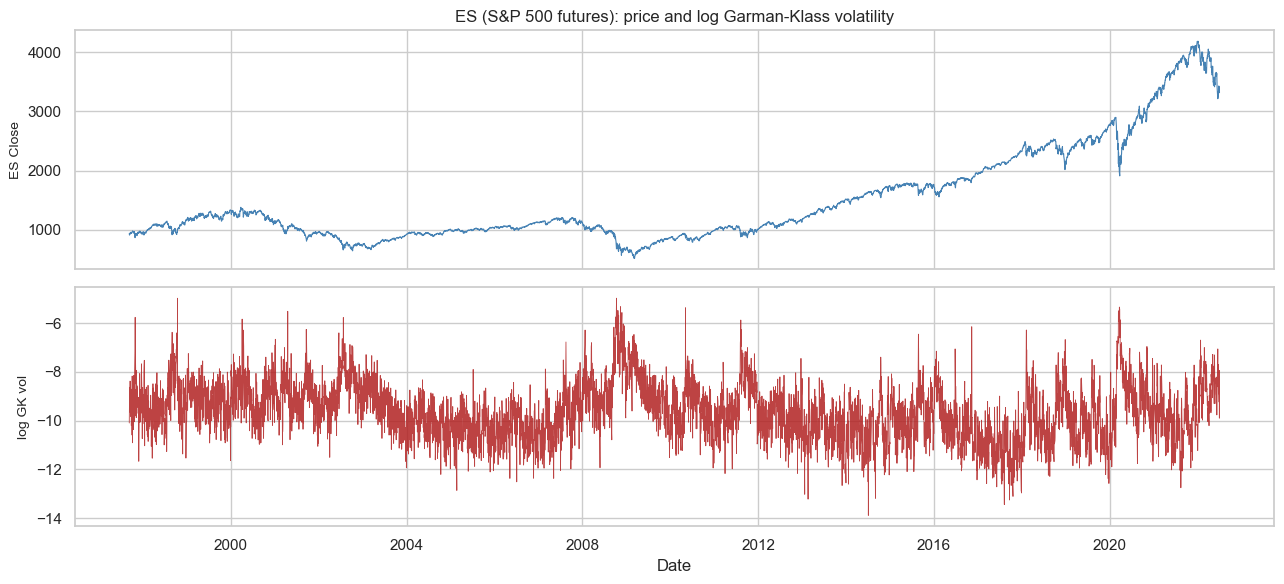

ES log-GK vol summary:
count    6296.000
mean       -9.627
std         1.169
min       -13.888
25%       -10.451
50%        -9.655
75%        -8.871
max        -4.981


In [2]:
def garman_klass_logvol(df: pd.DataFrame) -> pd.Series:
    """σ²_GK = 0.5*(ln H/L)² – (2 ln 2 – 1)*(ln C/O)²  →  log(max(σ²_GK, ε))."""
    ln_hl = np.log(df["high"] / df["low"])
    ln_co = np.log(df["close"] / df["open"])
    gk    = 0.5 * ln_hl**2 - (2.0 * np.log(2.0) - 1.0) * ln_co**2
    return np.log(np.maximum(gk, 1e-10))

# Visualise log GK vol for ES (equity index — clean, widely followed)
es = ohlcv[ohlcv["instrument"] == "es1s"].sort_values("date").set_index("date")
es_vol = garman_klass_logvol(es)

fig, axes = plt.subplots(2, 1, figsize=(13, 6), sharex=True)

axes[0].plot(es.index, es["close"], lw=0.8, color="steelblue")
axes[0].set_ylabel("ES Close", fontsize=10)
axes[0].set_title("ES (S&P 500 futures): price and log Garman-Klass volatility", fontsize=12)
axes[0].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

axes[1].plot(es_vol.index, es_vol, lw=0.6, color="firebrick", alpha=0.85)
axes[1].set_ylabel("log GK vol", fontsize=10)
axes[1].set_xlabel("Date")

plt.tight_layout()
plt.savefig("_tmp_nb1_gkvol.png", dpi=120, bbox_inches="tight")
plt.show()
print(f"ES log-GK vol summary:\n{es_vol.describe().round(3).to_string()}")


---
<a id="split"></a>
## 2  Pre-Sample Split and Standardisation

The 645-day primary-signals window runs **2020-01-03 → 2022-06-30**.
Everything before 2020-01-03 is the **pre-sample** used exclusively for fitting.

Standardisation is computed from **pre-sample statistics only** (mean and std of the
log-GK series on the pre-sample), then the same scaler is applied to the full
sequence before filtering.  Fitting the scaler on the full sequence (including the
metamodel window) would constitute a form of data leakage.


Pre-sample: 1997-09-09 → 2020-01-02  (5,667 days)
Meta window: 2020-01-03 → 2022-06-30  (629 days)
Pre-sample μ=-9.664  σ=1.154  (used to standardise both splits)


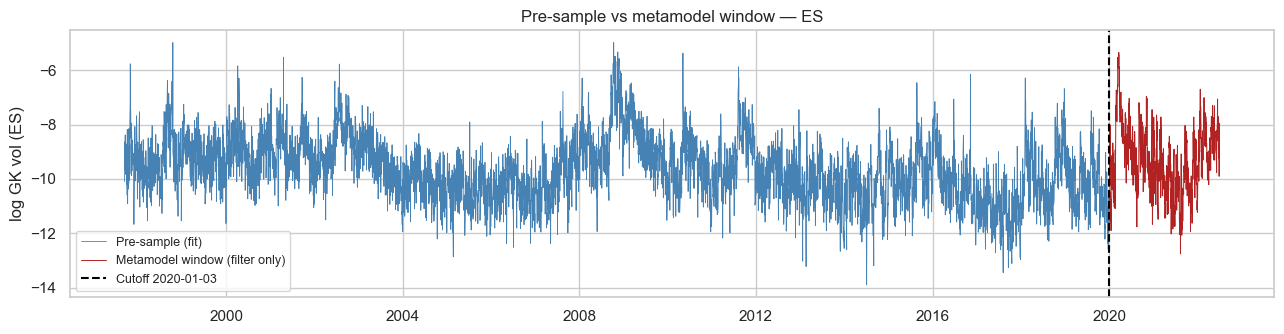

In [3]:
# Demonstrate the split for ES
es_pre  = es_vol[es_vol.index <  CUTOFF]
es_meta = es_vol[es_vol.index >= CUTOFF]

mu_pre  = es_pre.mean()
sig_pre = es_pre.std()

print(f"Pre-sample: {es_pre.index.min().date()} → {es_pre.index.max().date()}  ({len(es_pre):,} days)")
print(f"Meta window: {es_meta.index.min().date()} → {es_meta.index.max().date()}  ({len(es_meta):,} days)")
print(f"Pre-sample μ={mu_pre:.3f}  σ={sig_pre:.3f}  (used to standardise both splits)")

fig, ax = plt.subplots(figsize=(13, 3.5))
ax.plot(es_pre.index,  es_pre,  lw=0.6, color="steelblue",  label="Pre-sample (fit)")
ax.plot(es_meta.index, es_meta, lw=0.7, color="firebrick",   label="Metamodel window (filter only)")
ax.axvline(CUTOFF, color="black", lw=1.5, ls="--", label=f"Cutoff {CUTOFF.date()}")
ax.set_ylabel("log GK vol (ES)"); ax.set_title("Pre-sample vs metamodel window — ES")
ax.legend(fontsize=9)
plt.tight_layout(); plt.savefig("_tmp_nb1_split.png", dpi=120, bbox_inches="tight"); plt.show()


---
<a id="design"></a>
## 3  Fit-and-Freeze Design — Why It Is Leakage-Free

Following the HMM framework from Rabiner (1989) and the course Session 3 notebook,
we parameterise the model as $\lambda = (\pi, Q, \theta)$:

| Symbol | Dimension | Meaning |
|--------|-----------|---------|
| $\pi$ | $(M,)$ | Initial state distribution $\pi_m = P(H_1 = m)$ |
| $Q$ | $(M \times M)$ | Transition matrix: $Q_{ij} = P(H_{t+1}=j \mid H_t=i)$ |
| $\theta$ | per state | Gaussian emission: $p(x_t \mid H_t=m) = \mathcal{N}(x_t;\,\mu_m,\sigma^2_m)$ |

**Fit:** Baum-Welch EM is run on the pre-sample (before 2020-01-03).  All
parameters are then **frozen**.

**Filter-forward (not smoothing):**

$$\alpha_t(m) = P(H_t = m \mid X_1, \ldots, X_t), \qquad t = 1, \ldots, T$$

computed via the scaled forward recursion (Rabiner eq. 19–20):

$$\alpha_0(m) \propto \pi_m \cdot p(x_0 \mid H_0 = m)$$
$$\alpha_t(m) \propto \left[\sum_{m'} \alpha_{t-1}(m') \cdot Q_{m'm}\right] \cdot p(x_t \mid H_t = m)$$

This is **causal**: at date $t$, only observations $X_1, \ldots, X_t$ are used.
Smoothing (forward-backward) would condition on the full future sequence
$X_1, \ldots, X_T$, which would leak tomorrow's realised volatility into today's
feature — invalid for any backtest or live trading application.

The forward pass runs on the **complete sequence** (pre-sample + metamodel) so that
the state distribution at the start of the metamodel window is correctly conditioned
on the full history.  Only the rows falling in the metamodel window are extracted
as features; no refitting occurs.


In [4]:
def _gaussian_log_emit(X, means, covars):
    """log p(x_t | H_t=m) for each (t,m).  Handles covars shape (M,d) or (M,d,d)."""
    T, M = X.shape[0], len(means)
    log_emit = np.empty((T, M))
    for m in range(M):
        mu  = means[m]
        c   = covars[m]
        var = np.diag(c) if c.ndim == 2 else c      # σ² diagonal
        log_emit[:, m] = -0.5 * (
            np.sum(((X - mu)**2) / var, axis=1) + np.sum(np.log(2*np.pi*var))
        )
    return log_emit


def filter_forward(model, X):
    """
    Scaled forward algorithm → filtering posteriors p(H_t | X_1:t).

    Recursion (log-domain, logsumexp normalisation):
        log α_t(m) = logsumexp_m'[log α_{t-1}(m') + log Q_{m'm}] + log p(x_t|H_t=m)
        log α_t   -= logsumexp(log α_t)         # normalise to sum-to-1

    Returns: (T, M) array of filtering probabilities, rows sum to 1.
    """
    T, M = X.shape[0], model.n_components
    log_emit = _gaussian_log_emit(X, model.means_, model.covars_)
    log_pi   = np.log(np.clip(model.startprob_, 1e-300, 1.0))
    log_Q    = np.log(np.clip(model.transmat_,  1e-300, 1.0))

    log_alpha = log_pi + log_emit[0]
    log_alpha -= logsumexp(log_alpha)
    filtered = np.empty((T, M))
    filtered[0] = np.exp(log_alpha)

    for t in range(1, T):
        log_alpha = logsumexp(log_alpha[:, None] + log_Q, axis=0) + log_emit[t]
        log_alpha -= logsumexp(log_alpha)
        filtered[t] = np.exp(log_alpha)
    return filtered

print("filter_forward defined — causal, no future data used.")


filter_forward defined — causal, no future data used.


---
<a id="fit"></a>
## 4  EM Fitting with Multiple Random Restarts

The Baum-Welch algorithm maximises the expected complete-data log-likelihood
(E-step / M-step) but is guaranteed only to reach a **local optimum**.
Different random initialisations can converge to different solutions.

We run **20 independent restarts** per instrument (varying `random_state`) and
keep the solution with the highest log-likelihood on the pre-sample.  This is
the standard heuristic for mitigating EM local-optima.

**State ordering** is enforced after fitting: states are re-indexed so that
the Gaussian mean is ascending — state 0 = calm (lowest log-vol), state 1 = moderate,
state 2 = turbulent.  This makes the state label deterministic across restarts and
across instruments.


In [5]:
def fit_hmm_best(X, n_states=3, n_restarts=20, n_iter=300, base_seed=42):
    """Multiple-restart EM; returns (best_model, best_log_lik)."""
    best, best_ll = None, -np.inf
    for i in range(n_restarts):
        m = GaussianHMM(n_components=n_states, covariance_type="diag",
                        n_iter=n_iter, random_state=base_seed+i, tol=1e-5)
        try:
            m.fit(X)
            ll = m.score(X)
            if np.isfinite(ll) and ll > best_ll:
                best_ll, best = ll, m
        except Exception:
            pass
    return best, best_ll


def sort_states_by_mean(model):
    """Reorder states by ascending emission mean: state 0 = calm."""
    order = np.argsort(model.means_.flatten())
    model.startprob_ = model.startprob_[order]
    model.transmat_  = model.transmat_[np.ix_(order, order)]
    model.means_     = model.means_[order]
    model._covars_   = model._covars_[order]   # compact (M,d); bypass shape-checking setter
    return model


# Fit all 11 instruments
fitted_models = {}
presample_stats = {}

print(f"{'Instrument':10s}  {'log-lik':>10s}  {'State means (log GK vol, de-standardised)'}")
print("-"*75)
for inst in INSTRUMENTS:
    df = ohlcv[ohlcv["instrument"]==inst].sort_values("date").set_index("date")
    lv = garman_klass_logvol(df).dropna()

    pre  = lv[lv.index < CUTOFF]
    mu, s = pre.mean(), pre.std()
    presample_stats[inst] = (mu, s)

    X_pre = ((pre - mu)/s).values.reshape(-1,1)

    model, ll = fit_hmm_best(X_pre, n_states=N_STATES, n_restarts=N_RESTARTS)
    model = sort_states_by_mean(model)
    fitted_models[inst] = model

    raw_means = (model.means_.flatten() * s + mu).round(3)
    print(f"  {inst:8s}  {ll:10.2f}  {raw_means}")


Instrument     log-lik  State means (log GK vol, de-standardised)
---------------------------------------------------------------------------


  es1s        -6048.22  [-10.635  -9.46   -8.26 ]


  nq1s        -5083.56  [-10.011  -8.819  -7.344]


  fesx1s      -5848.05  [-10.123  -9.04   -7.755]


  cl1s        -8556.58  [-9.478 -8.302 -7.286]


...

  ng1s        -8051.64  [-9.981 -8.051 -6.958]


  gc1s        -8392.73  [-11.367 -10.026  -8.845]


  si1s        -8760.89  [-9.551 -8.604 -7.523]


  hg1s        -8655.94  [-9.564 -8.666 -7.459]


  pl1s        -8941.28  [-10.223  -9.177  -8.08 ]


---
<a id="params"></a>
## 5  Learned Parameters

### 5.1  Transition Matrix and Dwell Times (ES)

The diagonal of $Q$ gives the persistence probability of each state.  The expected
dwell time in state $m$ is $\mathbb{E}[d_m] = 1 / (1 - Q_{mm})$.

Robust regimes have long dwell times (days to weeks), confirming that the states
correspond to genuine market regimes rather than noise.


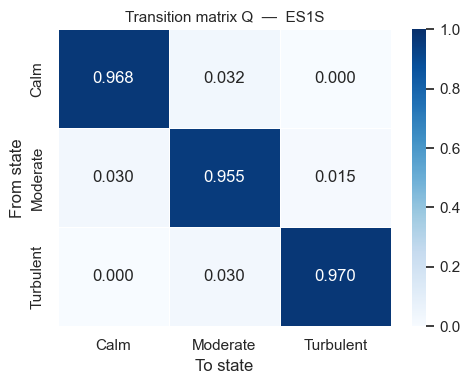

Expected dwell times (1 / (1 - Q_ii)):
  Calm        :  31.0 trading days
  Moderate    :  22.4 trading days
  Turbulent   :  32.9 trading days


In [6]:
inst = "es1s"
model = fitted_models[inst]
Q = model.transmat_

# Transition matrix heatmap
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(
    pd.DataFrame(Q, index=["Calm","Moderate","Turbulent"],
                    columns=["Calm","Moderate","Turbulent"]),
    annot=True, fmt=".3f", cmap="Blues", vmin=0, vmax=1,
    linewidths=0.5, ax=ax
)
ax.set_title(f"Transition matrix Q  —  {inst.upper()}", fontsize=11)
ax.set_ylabel("From state"); ax.set_xlabel("To state")
plt.tight_layout(); plt.savefig("_tmp_nb1_transmat.png", dpi=120, bbox_inches="tight"); plt.show()

print("Expected dwell times (1 / (1 - Q_ii)):")
for i, name in enumerate(["Calm","Moderate","Turbulent"]):
    dwell = 1.0 / (1.0 - Q[i, i])
    print(f"  {name:12s}: {dwell:5.1f} trading days")


Per-state log GK vol means (de-standardised, i.e. in original log-vol units):
            calm (state 0)  moderate (state 1)  turbulent (state 2)
instrument                                                         
es1s               -10.635              -9.460               -8.260
nq1s               -10.011              -8.819               -7.344
fesx1s             -10.123              -9.040               -7.755
cl1s                -9.478              -8.302               -7.286
ho1s                -9.368              -8.428               -7.547
rb1s                -8.950              -7.971               -6.847
ng1s                -9.981              -8.051               -6.958
gc1s               -11.367             -10.026               -8.845
si1s                -9.551              -8.604               -7.523
hg1s                -9.564              -8.666               -7.459
pl1s               -10.223              -9.177               -8.080


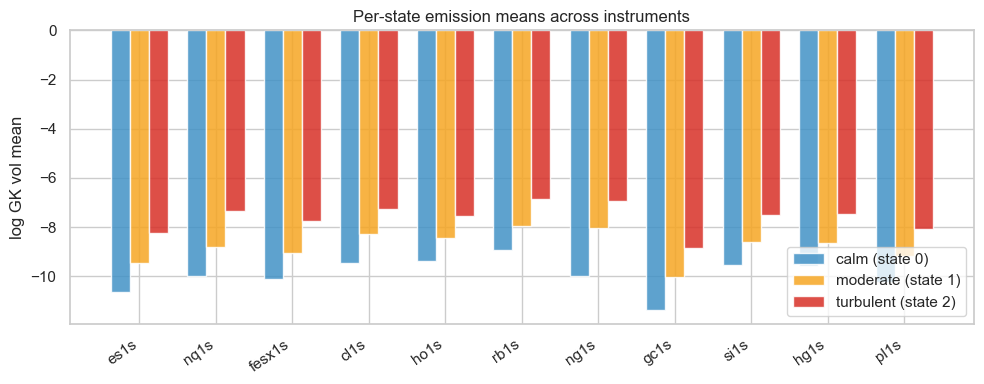

In [7]:
# Per-state emission means across all instruments (de-standardised)
rows = []
for inst in INSTRUMENTS:
    m = fitted_models[inst]
    mu, s = presample_stats[inst]
    means = m.means_.flatten() * s + mu   # de-standardise
    rows.append({
        "instrument": inst,
        "calm (state 0)":      round(means[0], 3),
        "moderate (state 1)":  round(means[1], 3),
        "turbulent (state 2)": round(means[2], 3),
    })
means_df = pd.DataFrame(rows).set_index("instrument")
print("Per-state log GK vol means (de-standardised, i.e. in original log-vol units):")
print(means_df.to_string())

# Visualise
fig, ax = plt.subplots(figsize=(10, 4))
x = np.arange(len(INSTRUMENTS))
w = 0.25
for k, (col, color) in enumerate(zip(means_df.columns, ["#4292c6","#f6a623","#d73027"])):
    ax.bar(x + k*w, means_df[col], width=w, label=col, color=color, alpha=0.85)
ax.set_xticks(x + w)
ax.set_xticklabels(INSTRUMENTS, rotation=35, ha="right")
ax.set_ylabel("log GK vol mean"); ax.set_title("Per-state emission means across instruments")
ax.legend(); plt.tight_layout()
plt.savefig("_tmp_nb1_means.png", dpi=120, bbox_inches="tight"); plt.show()


---
<a id="regime"></a>
## 6  Regime-Over-Time Plot

We run the **full** forward filter on the pre-sample + metamodel sequence for ES
to visualise regime evolution.  The Viterbi most-likely state sequence is
overlaid on the log-vol series.

Note: the plot uses the **filtering** posterior argmax, not Viterbi (which requires
the full sequence and would use future info).  In practice, for diagnostics the
difference is minor, but for features we always use the filtering probabilities.


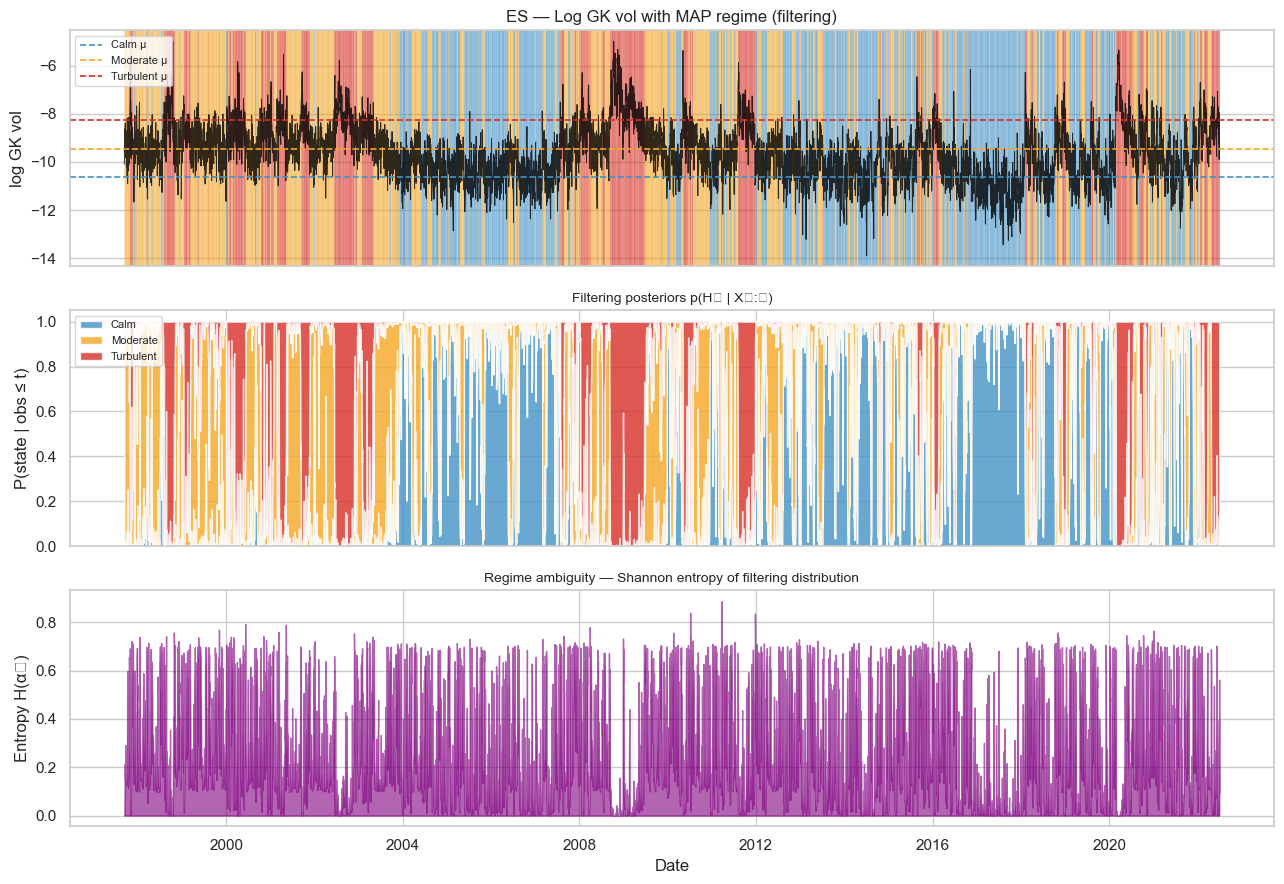

In [8]:
inst = "es1s"
model = fitted_models[inst]
mu, s = presample_stats[inst]

df = ohlcv[ohlcv["instrument"]==inst].sort_values("date").set_index("date")
lv = garman_klass_logvol(df).dropna()
X_full = ((lv - mu)/s).values.reshape(-1,1)

filtered = filter_forward(model, X_full)
MAP_state = np.argmax(filtered, axis=1)   # most probable state at each t

state_colors = ["#4292c6", "#f6a623", "#d73027"]
state_labels = ["Calm", "Moderate", "Turbulent"]

fig, axes = plt.subplots(3, 1, figsize=(13, 9), sharex=True)

# Top: log GK vol coloured by MAP state
axes[0].set_title("ES — Log GK vol with MAP regime (filtering)", fontsize=12)
for t in range(len(lv)):
    axes[0].axvline(lv.index[t], color=state_colors[MAP_state[t]], lw=0.4, alpha=0.25)
axes[0].plot(lv.index, lv.values, lw=0.7, color="black", alpha=0.8)
axes[0].set_ylabel("log GK vol")
for s_idx, (lbl, col) in enumerate(zip(state_labels, state_colors)):
    axes[0].axhline(model.means_[s_idx, 0]*s + mu, color=col, ls="--", lw=1.2, label=f"{lbl} μ")
axes[0].legend(fontsize=8, loc="upper left")

# Middle: filtering probabilities stacked
axes[1].stackplot(
    lv.index, filtered[:,0], filtered[:,1], filtered[:,2],
    labels=state_labels, colors=state_colors, alpha=0.8
)
axes[1].set_ylabel("P(state | obs ≤ t)")
axes[1].legend(loc="upper left", fontsize=8)
axes[1].set_title("Filtering posteriors p(Hₜ | X₁:ₜ)", fontsize=10)

# Bottom: entropy
entropy = -np.sum(filtered * np.log(np.clip(filtered, 1e-300, 1)), axis=1)
axes[2].fill_between(lv.index, entropy, alpha=0.6, color="purple")
axes[2].set_ylabel("Entropy H(αₜ)"); axes[2].set_xlabel("Date")
axes[2].set_title("Regime ambiguity — Shannon entropy of filtering distribution", fontsize=10)
axes[2].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

plt.tight_layout(); plt.savefig("_tmp_nb1_regime.png", dpi=120, bbox_inches="tight"); plt.show()


---
<a id="dwell"></a>
## 7  Dwell-Time Sanity Check

Expected dwell time in state $m$:

$$\mathbb{E}[d_m] = \frac{1}{1 - Q_{mm}}$$

Long dwell times (≫1 day) confirm that states represent persistent economic
regimes, not noise.  If dwell times were $\approx 1$ day the hidden state would
be flipping on every tick — economically meaningless.


Expected dwell times (trading days):
state       Calm  Moderate  Turbulent
instrument                           
cl1s        60.6      51.6       27.8
es1s        31.0      22.4       32.9
fesx1s      35.0      28.0       29.5
gc1s        49.9      44.2       39.0
hg1s        69.3      51.2       33.1
ho1s        58.1      39.2       27.8
ng1s        25.4      46.8       48.6
nq1s        37.8      20.0       38.8
pl1s        32.7      28.3       18.1
rb1s        57.2      77.1       20.4
si1s        68.3      38.2       30.3


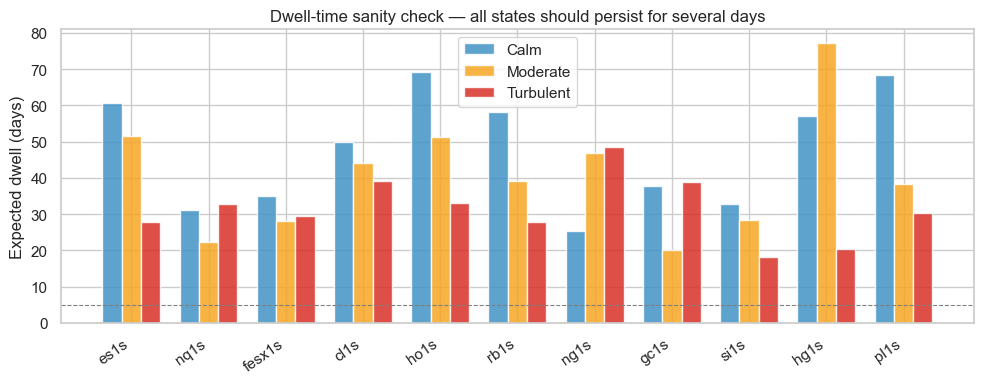

In [9]:
rows = []
for inst in INSTRUMENTS:
    m   = fitted_models[inst]
    Q   = m.transmat_
    for s_idx, name in enumerate(["Calm","Moderate","Turbulent"]):
        dwell = 1.0 / (1.0 - Q[s_idx, s_idx])
        rows.append({"instrument": inst, "state": name, "expected_dwell_days": round(dwell, 1)})

dwell_df = pd.DataFrame(rows)
pivot    = dwell_df.pivot(index="instrument", columns="state", values="expected_dwell_days")
print("Expected dwell times (trading days):")
print(pivot.to_string())

fig, ax = plt.subplots(figsize=(10, 4))
x = np.arange(len(INSTRUMENTS))
w = 0.25
for k, (col_name, color) in enumerate(zip(["Calm","Moderate","Turbulent"], ["#4292c6","#f6a623","#d73027"])):
    ax.bar(x + k*w, pivot[col_name], width=w, label=col_name, color=color, alpha=0.85)
ax.set_xticks(x + w)
ax.set_xticklabels(INSTRUMENTS, rotation=35, ha="right")
ax.set_ylabel("Expected dwell (days)")
ax.set_title("Dwell-time sanity check — all states should persist for several days")
ax.legend(); ax.axhline(5, ls="--", color="grey", lw=0.8, label="5-day threshold")
plt.tight_layout(); plt.savefig("_tmp_nb1_dwell.png", dpi=120, bbox_inches="tight"); plt.show()


---
<a id="filter"></a>
## 8  Filter-Forward into the Metamodel Window

We run the scaled forward pass on the **full** sequence (pre-sample + metamodel)
for each instrument, then extract only the rows in the 645-day window.

This is the correct approach:
- Parameters are **frozen** (estimated on pre-sample only).
- At each date $t$ in the metamodel window, the filter only has access to
  observations up to $t$ — strictly causal.
- Running the filter from the start of history (rather than re-initialising
  at the metamodel cutoff) means the state distribution at day 1 of the
  metamodel window is properly conditioned on 30 years of prior history.


In [10]:
records = []

for inst in INSTRUMENTS:
    model = fitted_models[inst]
    mu, s = presample_stats[inst]

    df  = ohlcv[ohlcv["instrument"]==inst].sort_values("date").set_index("date")
    lv  = garman_klass_logvol(df).dropna()
    X_f = ((lv - mu)/s).values.reshape(-1,1)

    filtered   = filter_forward(model, X_f)
    full_dates = lv.index
    Q = model.transmat_
    TURB = N_STATES - 1   # index of turbulent state (sorted)

    for idx, d in enumerate(full_dates):
        if d not in META_DATES:
            continue
        alpha = filtered[idx]
        records.append({
            "date":                   d,
            "instrument":             inst,
            "hmm_vol_p0_calm":        float(alpha[0]),
            "hmm_vol_p2_turbulent":   float(alpha[2]),
            "hmm_vol_next_turbulent": float(alpha @ Q[:, TURB]),
            "hmm_vol_entropy":        float(-np.sum(alpha * np.log(np.clip(alpha,1e-300,1.0)))),
        })

features_vol = pd.DataFrame(records).sort_values(["date","instrument"]).reset_index(drop=True)
print(f"Feature matrix shape: {features_vol.shape}  (dates × instruments = {features_vol['date'].nunique()} × {features_vol['instrument'].nunique()})")


Feature matrix shape: (6919, 6)  (dates × instruments = 645 × 11)


---
<a id="features"></a>
## 9  Feature Extraction and Preview

### Feature definitions

| Feature | Formula | Interpretation |
|---------|---------|---------------|
| `hmm_vol_p0_calm` | $\alpha_t[0]$ | Probability we are currently in the calm regime |
| `hmm_vol_p2_turbulent` | $\alpha_t[2]$ | Probability we are in the turbulent regime |
| `hmm_vol_next_turbulent` | $\alpha_t \cdot Q_{:,2}$ | One-step forecast: P(turbulent tomorrow) |
| `hmm_vol_entropy` | $-\sum_m \alpha_t[m]\ln\alpha_t[m]$ | Regime ambiguity — high near transitions |

`p1` (moderate) is dropped because $p_0 + p_1 + p_2 = 1$, making it redundant.

### Cross-sectional preview (2020-01-03)


In [11]:
print("First date preview:")
print(features_vol[features_vol["date"] == features_vol["date"].min()].to_string(index=False))

print()
print("Feature summary statistics:")
print(features_vol.describe().round(4).to_string())


First date preview:
      date instrument  hmm_vol_p0_calm  hmm_vol_p2_turbulent  hmm_vol_next_turbulent  hmm_vol_entropy
2020-01-03       cl1s         0.465225              0.059048                0.064326         0.876499
2020-01-03       es1s         0.717468              0.000423                0.004581         0.598502
2020-01-03     fesx1s         0.825462              0.000366                0.002638         0.465635
2020-01-03       gc1s         0.534879              0.005770                0.012682         0.721775
2020-01-03       hg1s         0.947944              0.001564                0.003108         0.211547
2020-01-03       ho1s         0.860215              0.037342                0.039580         0.485703
2020-01-03       ng1s         0.001095              0.037291                0.052663         0.167752
2020-01-03       nq1s         0.871782              0.000074                0.002034         0.383612
2020-01-03       pl1s         0.005788              0.110711  

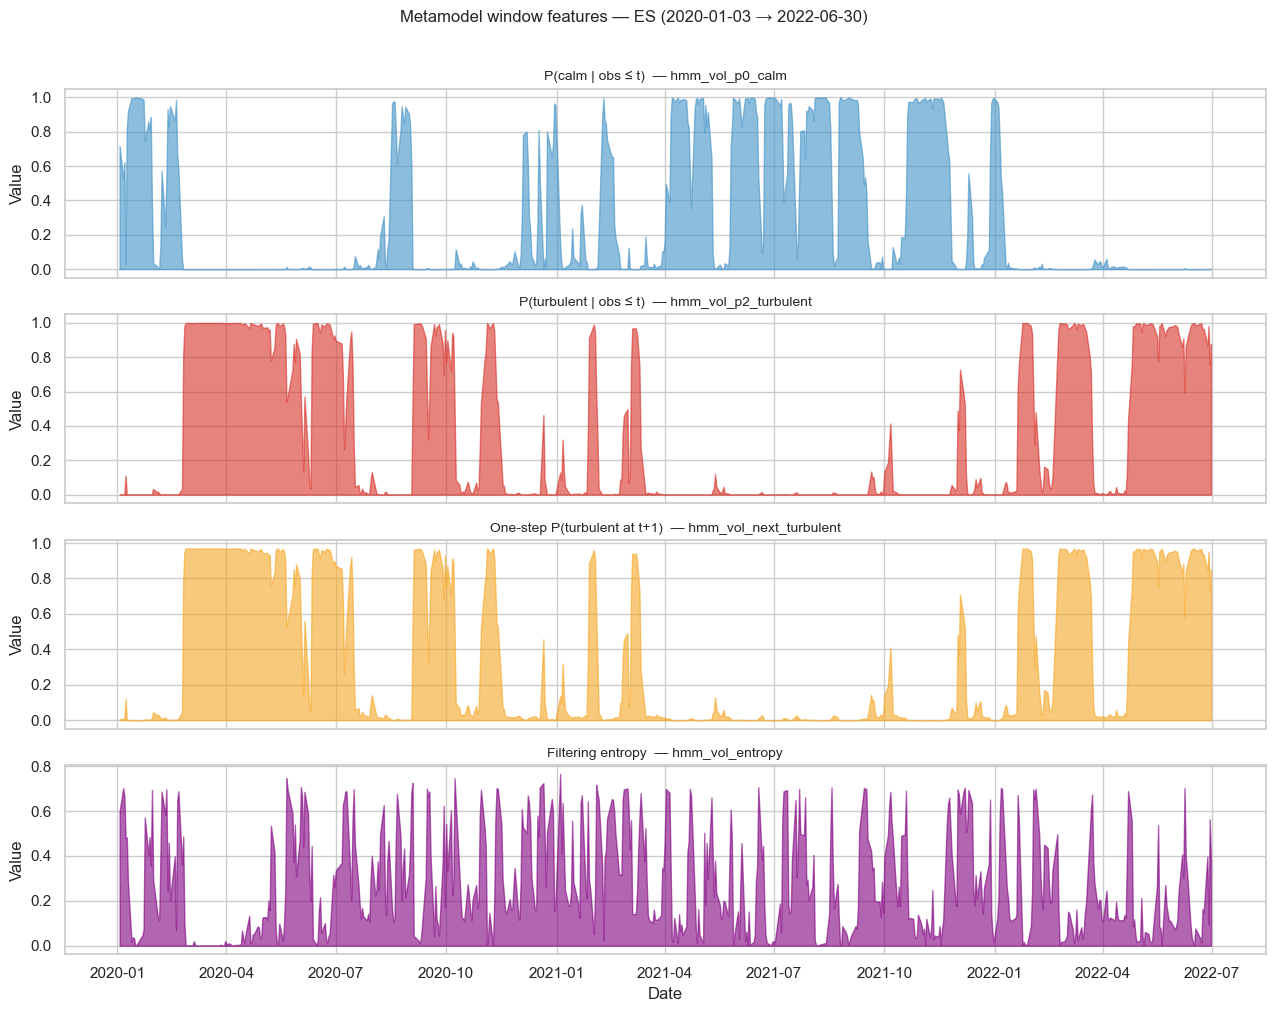

In [12]:
# Time-series plot of the features for ES
es_feat = features_vol[features_vol["instrument"] == "es1s"].set_index("date")

fig, axes = plt.subplots(4, 1, figsize=(13, 10), sharex=True)
titles = [
    "P(calm | obs ≤ t)  — hmm_vol_p0_calm",
    "P(turbulent | obs ≤ t)  — hmm_vol_p2_turbulent",
    "One-step P(turbulent at t+1)  — hmm_vol_next_turbulent",
    "Filtering entropy  — hmm_vol_entropy",
]
cols  = ["hmm_vol_p0_calm","hmm_vol_p2_turbulent","hmm_vol_next_turbulent","hmm_vol_entropy"]
colors = ["#4292c6","#d73027","#f6a623","purple"]

for ax, col, title, color in zip(axes, cols, titles, colors):
    ax.fill_between(es_feat.index, es_feat[col], alpha=0.6, color=color)
    ax.set_title(title, fontsize=10); ax.set_ylabel("Value")
axes[-1].set_xlabel("Date")
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
plt.suptitle("Metamodel window features — ES (2020-01-03 → 2022-06-30)", fontsize=12, y=1.01)
plt.tight_layout(); plt.savefig("_tmp_nb1_features.png", dpi=120, bbox_inches="tight"); plt.show()


In [13]:
# Save (also saved by the standalone pipeline script)
features_vol.to_csv(OUT_PATH, index=False)
print(f"Saved {len(features_vol):,} rows → {OUT_PATH}")
print("\nDone.  Features ready to merge into metamodel by (date, instrument).")


Saved 6,919 rows → /Users/harrybrowne/Downloads/Imperial Work/SystematicTrading/stml/src/stml/new_work/features_hmm_vol.csv

Done.  Features ready to merge into metamodel by (date, instrument).
